## Задание 5. Исследовательское задание: малоранговая аппроксимация матрицы

Сгенерируйте случайную квадратную матрицу

$$
A \in \mathbb{R}^{n \times n}, \quad n \ge 100
$$

С помощью функции numpy.linalg.svd выполните сингулярное разложение этой матрицы и получите три матрицы:

$$
U, \; S, \; V^T
$$

Выполняйте аппроксимацию матрицы A матрицей ранга r, меняя его значение, например, от 2 до n:

$$
\tilde{A} = U[:, :r] \, S[:r, :r] \, V^T[:r, :]
$$

каждый раз считайте ошибку аппроксимации (как восстановленная матрица отличается от исходной):

$$
E(r) = \|A - \tilde{A}\|_F = 
\sqrt{
\sum_{i=1}^{n}
\sum_{j=1}^{n}
\left(a_{ij} - \tilde{a}_{ij}\right)^2
}
$$

Используя библиотеку matplotlib, постройте график зависимости ошибки аппроксимации матрицы от ранга r.

### Решение
#### 1. Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 2. Генерация случайно матрицы 

Сгенерируем случайную квадратную матрицу размера

$$
100 \times 100
$$

In [2]:
n = 100
A = np.random.rand(n, n)

A[:5, :5]

array([[0.96237473, 0.23186651, 0.77306915, 0.13052696, 0.40909261],
       [0.51410753, 0.91594749, 0.92748356, 0.4329444 , 0.77733905],
       [0.17242323, 0.6686936 , 0.08050495, 0.560765  , 0.76099538],
       [0.19926345, 0.09864332, 0.72730568, 0.53317362, 0.4515927 ],
       [0.24691574, 0.28475163, 0.69346997, 0.65364838, 0.08685021]])

### 3. Сингулярное разложение
Выполним сингулярное разложение матрицы с использованием функции

numpy.linalg.svd.

В результате получаем разложение

$$
A = U S V^T
$$

In [3]:
U, s, Vt = np.linalg.svd(A, full_matrices=False)

S = np.diag(s)

### 4. Малоранговая аппроксимация

Будем изменять ранг $r$ и строить приближенную матрицу

$$
\tilde{A} = U[:, :r] S[:r,:r] V^T[:r,:]
$$

Для каждого значения ранга будем вычислять ошибку

$$
E(r) = \|A - \tilde{A}\|_F
$$

In [4]:
r_values = range(2, n + 1)
errors = []

for r in r_values:
    
    A_tilde = U[:, :r] @ S[:r, :r] @ Vt[:r, :]
    
    error = np.linalg.norm(A - A_tilde, ord='fro')
    
    errors.append(error)

## 5. Построение графика 
Построим график зависимости ошибки аппроксимации матрицы от ранга $r$.

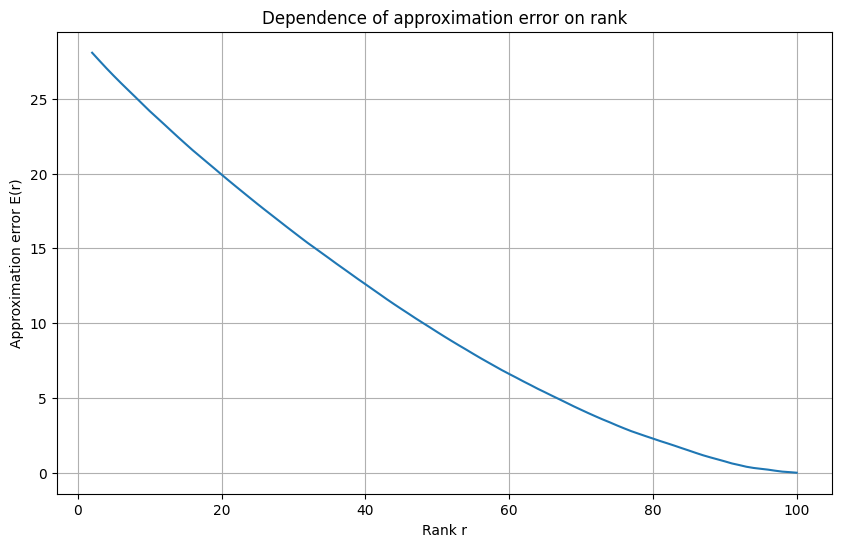

In [5]:
plt.figure(figsize=(10,6))

plt.plot(r_values, errors)

plt.xlabel("Rank r")
plt.ylabel("Approximation error E(r)")
plt.title("Dependence of approximation error on rank")

plt.grid(True)

plt.show()

## Вывод 

В ходе работы была исследована малоранговая аппроксимация случайной матрицы с использованием сингулярного разложения.

При увеличении ранга $r$ ошибка аппроксимации уменьшается.  
Это происходит потому, что при увеличении числа используемых сингулярных значений приближенная матрица становится всё ближе к исходной.

При $r = n$ восстановленная матрица совпадает с исходной и ошибка стремится к нулю.